In [ ]:
import numpy as np 
from utils import *

In [2]:
# load data
zs = np.array([0.0, 0.2, 0.5, 1.0, 1.5, 2.0])

sim_names = ['kn1-Repos1', 'kn1-DF', 'kn1S-Repos1', 'kn1S-DF']

kbh_Repos1 = get_kBH_end_zs(sim_names[0], zs, halo_info=True)
kbh_DF = get_kBH_end_zs(sim_names[1], zs, halo_info=True)
kbh_SRepos1 = get_kBH_end_zs(sim_names[2], zs, halo_info=True)
kbh_SDF = get_kBH_end_zs(sim_names[3], zs, halo_info=True)

Updating FirstReleaseTime of BHID 293032791 from 0.24117171640611984 to 0.2409724162921851 (from swallowed BHID 292219365)
Updating FirstReleaseTime of BHID 295070536 from 0.2619989123646749 to 0.2409724162921851 (from swallowed BHID 293032791)
Updating FirstReleaseTime of BHID 295899988 from 0.29121276986968453 to 0.2409724162921851 (from swallowed BHID 295070536)
Updating FirstReleaseTime of BHID 524201326 from 0.31990002990553174 to 0.2562380387965549 (from swallowed BHID 524195549)
Updating FirstReleaseTime of BHID 387659171 from 0.33098322890009513 to 0.32157787143554983 (from swallowed BHID 387255346)
Updating FirstReleaseTime of BHID 296720444 from 0.344440492749062 to 0.2409724162921851 (from swallowed BHID 295899988)
Updating FirstReleaseTime of BHID 298360777 from 0.3517932606046014 to 0.2409724162921851 (from swallowed BHID 296720444)
Updating FirstReleaseTime of BHID 433003952 from 0.3555821972248517 to 0.3486578631967217 (from swallowed BHID 428888739)
Updating FirstReleas

Total energy density (from 1.0e+10 to 5.0e+14 Msun/h): 1.071e+03 c^2 Msun/h / (Mpc/h)^3
Total energy density (from 1.0e+10 to 5.0e+14 Msun/h): 1.233e+03 c^2 Msun/h / (Mpc/h)^3
Total energy density (from 1.0e+10 to 5.0e+14 Msun/h): 1.289e+03 c^2 Msun/h / (Mpc/h)^3
Total energy density (from 1.0e+10 to 5.0e+14 Msun/h): 1.418e+03 c^2 Msun/h / (Mpc/h)^3
Total energy density (from 1.0e+10 to 5.0e+14 Msun/h): 5.258e+01 c^2 Msun/h / (Mpc/h)^3
Total energy density (from 1.0e+10 to 5.0e+14 Msun/h): 9.602e+01 c^2 Msun/h / (Mpc/h)^3
Total energy density (from 1.0e+10 to 5.0e+14 Msun/h): 1.337e+02 c^2 Msun/h / (Mpc/h)^3
Total energy density (from 1.0e+10 to 5.0e+14 Msun/h): 1.692e+02 c^2 Msun/h / (Mpc/h)^3


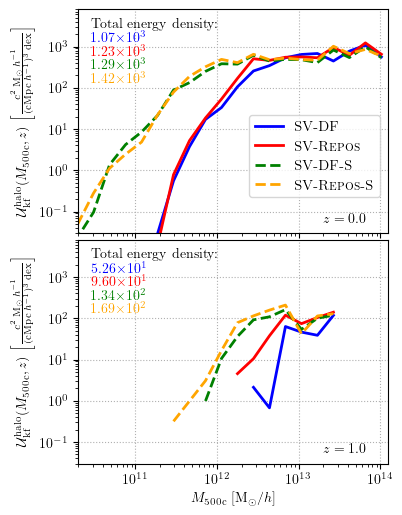

In [3]:
# 1x2 figure for redshifts (zs has 2 elements)

import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams['text.usetex'] = True
# font
plt.rcParams["font.family"] = 'Nimbus Roman'
plt.rcParams['mathtext.fontset'] = 'cm'

# zs = np.array([0.0, 0.5, 1.0, 1.5])
zs = np.array([0.0, 1.0])

m_lower = 1e10
m_upper = 5e14
bins = 24
colors = ['blue', 'red', 'green', 'orange']
lstyles = ['-', '-', '--', '--']
sim_names = [r'$\textsc{SV-DF}$', r'$\textsc{SV-Repos}$', r'$\textsc{SV-DF-S}$', r'$\textsc{SV-Repos-S}$']

def sci_notation(x, digits=2):
    return f'{x:.{digits}e}'[:-4] + r"$\times 10^{" + str(int(f'{x:.{digits}e}'.split('e')[1])) + r"}$"

fig, axs = plt.subplots(2,1, figsize=(4., 5.9), sharex=True, sharey=True)
fig.subplots_adjust(wspace=0.03, hspace=0.03)
axs = axs.flatten()

for i, z in enumerate(zs):
    ax = axs[i]
    if z in kbh_DF:
        u_tot_DF = plot_energy_density_distribution(
            ax,
            kbh_DF[z],
            nbins=bins,
            color=colors[0],
            xlower=m_lower,
            xupper=m_upper,
            label=sim_names[0],
            ls=lstyles[0],
            masstype='M500c'
            )
    if z in kbh_Repos1:
        u_tot_R1 = plot_energy_density_distribution(
            ax,
            kbh_Repos1[z],
            nbins=bins,
            color=colors[1],
            xlower=m_lower,
            xupper=m_upper,
            label=sim_names[1],
            ls=lstyles[1],
            masstype='M500c'
            )
    if z in kbh_SDF:
        u_tot_SDF = plot_energy_density_distribution(
            ax,
            kbh_SDF[z],
            nbins=bins,
            color=colors[2],
            xlower=m_lower,
            xupper=m_upper,
            label=sim_names[2],
            ls=lstyles[2],
            masstype='M500c'
            )
    if z in kbh_SRepos1:
        u_tot_SR1 = plot_energy_density_distribution(
            ax,
            kbh_SRepos1[z],
            nbins=bins,
            color=colors[3],
            xlower=m_lower,
            xupper=m_upper,
            label=sim_names[3],
            ls=lstyles[3],
            masstype='M500c'
            )
        
    # annotate total energy density for each model with different colors
    ax.text(0.04, .92, 'Total energy density:', transform=ax.transAxes)  # placeholder for alignment
    if z in kbh_DF:
        ax.text(0.04, 0.86, sci_notation(u_tot_DF), transform=ax.transAxes, color=colors[0])
    if z in kbh_Repos1:
        ax.text(0.04, 0.80, sci_notation(u_tot_R1), transform=ax.transAxes, color=colors[1])
    if z in kbh_SDF:
        ax.text(0.04, 0.74, sci_notation(u_tot_SDF), transform=ax.transAxes, color=colors[2])
    if z in kbh_SRepos1:
        ax.text(0.04, 0.68, sci_notation(u_tot_SR1), transform=ax.transAxes, color=colors[3])
    

    # ax.set_title(f'z = {z:.1f}')
    # annotate z using text instead of title
    ax.text(0.79, 0.05, r'$z = %.1f$' % z, transform=ax.transAxes)
    ax.set_xscale('log')
    ax.set_yscale('log')
    
    # x limit
    ax.set_xlim(2*m_lower, .25*m_upper)
    ax.set_ylim(3e-2, .8e4)
    ax.grid(ls=":")
    
    if i == 1: # bottom panel
        ax.set_xlabel(r'$M_\mathrm{500c}$ [M$_\odot/h$]')
    
    ax.set_ylabel(r'$\mathcal{U}_\mathrm{kf}^\mathrm{halo}(M_\mathrm{500c},z)$ $\left[\frac{c^2\,\mathrm{M}_\odot\,h^{-1}}{ (\mathrm{cMpc}\,h^{-1})^{3}\,\mathrm{dex} }\right]$')

    ax.label_outer()
    
# legend only for the first subplot
axs[0].legend(loc='lower left', bbox_to_anchor=(.53, 0.13))
# plt.tight_layout()
plt.show()